In [31]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [4]:
conn = sqlite3.connect("LargeBankingDB.db")

In [5]:
# show all tables in the database
query = """
SELECT name 
FROM sqlite_master 
WHERE type='table';
"""

tables = pd.read_sql_query(query, conn)
print(tables)


           name
0      Branches
1     Customers
2      Accounts
3  Transactions
4         Loans


In [6]:
query = "PRAGMA table_info(Customers);"
customers_columns = pd.read_sql_query(query, conn)
print(customers_columns)

   cid        name     type  notnull dflt_value  pk
0    0  CustomerID  INTEGER        0       None   1
1    1   FirstName     TEXT        0       None   0
2    2    LastName     TEXT        0       None   0
3    3      Gender     TEXT        0       None   0
4    4         DOB     DATE        0       None   0
5    5    BranchID  INTEGER        0       None   0


In [7]:
query = """
SELECT COUNT(*) AS MissingBranch
FROM Customers
WHERE BranchID IS NULL;
"""
pd.read_sql_query(query,conn)

,MissingBranch
0,0


In [8]:
query = "PRAGMA table_info(Branches);"
customers_columns = pd.read_sql_query(query, conn)
print(customers_columns)

   cid        name     type  notnull dflt_value  pk
0    0    BranchID  INTEGER        0       None   1
1    1  BranchName     TEXT        0       None   0
2    2        City     TEXT        0       None   0
3    3       State     TEXT        0       None   0


In [9]:
query = "PRAGMA table_info(Accounts);"
customers_columns = pd.read_sql_query(query, conn)
print(customers_columns)

   cid         name     type  notnull dflt_value  pk
0    0    AccountID  INTEGER        0       None   1
1    1   CustomerID  INTEGER        0       None   0
2    2  AccountType     TEXT        0       None   0
3    3      Balance     REAL        0       None   0
4    4  CreatedDate     DATE        0       None   0


In [10]:
query = "PRAGMA table_info(Transactions);"
customers_columns = pd.read_sql_query(query, conn)
print(customers_columns)

   cid             name     type  notnull dflt_value  pk
0    0    TransactionID  INTEGER        0       None   1
1    1        AccountID  INTEGER        0       None   0
2    2  TransactionType     TEXT        0       None   0
3    3           Amount     REAL        0       None   0
4    4  TransactionDate     DATE        0       None   0


In [11]:
query = "PRAGMA table_info(Loans);"
customers_columns = pd.read_sql_query(query, conn)
print(customers_columns)

   cid          name     type  notnull dflt_value  pk
0    0        LoanID  INTEGER        0       None   1
1    1    CustomerID  INTEGER        0       None   0
2    2      LoanType     TEXT        0       None   0
3    3        Amount     REAL        0       None   0
4    4     StartDate     DATE        0       None   0
5    5       EndDate     DATE        0       None   0
6    6  InterestRate     REAL        0       None   0


In [12]:
query = """ SELECT COUNT(*) FROM Customers """
pd.read_sql_query(query,conn)

,COUNT(*)
0,1000


In [13]:
query = """ SELECT COUNT(*) FROM Branches """
pd.read_sql_query(query,conn)

,COUNT(*)
0,10


In [14]:
query = """ SELECT COUNT(*) FROM Loans """
pd.read_sql_query(query,conn)

,COUNT(*)
0,500


In [15]:
query = """ SELECT COUNT(*) FROM Transactions """
pd.read_sql_query(query,conn)

,COUNT(*)
0,10000


In [16]:
query = """ SELECT COUNT(*) FROM Accounts """
pd.read_sql_query(query,conn)

,COUNT(*)
0,1200


In [17]:
query = """
SELECT COUNT(*)
FROM Accounts a
LEFT JOIN Customers c
ON a.CustomerID = c.CustomerID
WHERE c.CustomerID IS NULL;
"""
pd.read_sql_query(query,conn)

,COUNT(*)
0,0


In [18]:
query = """
SELECT COUNT(*)
FROM Transactions t
LEFT JOIN Accounts a
ON t.AccountID = a.AccountID
WHERE a.AccountID IS NULL;
"""
pd.read_sql_query(query,conn)

,COUNT(*)
0,0


In [19]:
query = """
SELECT COUNT(*)
FROM Loans l
LEFT JOIN Customers c
ON l.CustomerID = c.CustomerID
WHERE c.CustomerID IS NULL;
"""
pd.read_sql_query(query,conn)

,COUNT(*)
0,0


In [20]:
query = """
SELECT *
FROM Accounts
WHERE Balance < 0;
"""
pd.read_sql_query(query,conn)

,AccountID,CustomerID,AccountType,Balance,CreatedDate


In [21]:
query = """
SELECT *
FROM Transactions
WHERE Amount <= 0;
"""
pd.read_sql_query(query,conn)

,TransactionID,AccountID,TransactionType,Amount,TransactionDate


In [22]:
query = """
SELECT *
FROM Loans
WHERE Amount <= 0;
"""
pd.read_sql_query(query,conn)

,LoanID,CustomerID,LoanType,Amount,StartDate,EndDate,InterestRate


In [23]:
query = """
SELECT *
FROM Loans
WHERE InterestRate < 0 OR InterestRate > 100;
"""
pd.read_sql_query(query,conn)

,LoanID,CustomerID,LoanType,Amount,StartDate,EndDate,InterestRate


# Analysis 1: Branch Account Overview

**Objective:**
Identify which branches have the most accounts and the average account size per branch.

In [24]:
query = """
SELECT 
    b.BranchName,
    b.State,
    COUNT(a.AccountID) AS NumAccounts,
    AVG(a.Balance) AS AvgBalance,
    SUM(a.Balance) AS TotalBalance
FROM Accounts a
JOIN Customers c
    ON a.CustomerID = c.CustomerID
JOIN Branches b
    ON c.BranchID = b.BranchID
GROUP BY b.BranchName,b.State
ORDER BY NumAccounts DESC;
"""
df_branch_accounts = pd.read_sql_query(query,conn)
df_branch_accounts

,BranchName,State,NumAccounts,AvgBalance,TotalBalance
0,House-Reyes,Tennessee,152,49643.636316,7545832.72
1,"Love, Mcdaniel and Hall",Ohio,151,49864.670993,7529565.32
2,"Jones, Thomas and Boyd",Michigan,143,51834.149301,7412283.35
3,Reynolds and Sons,Kansas,127,52335.449134,6646602.04
4,King-Brown,South Carolina,114,50663.959474,5775691.38
5,Rice LLC,Oregon,111,50035.726036,5553965.59
6,"Brown, George and Ochoa",West Virginia,108,49144.263889,5307580.50
7,"Jones, Bird and Underwood",Florida,106,51509.574811,5460014.93
8,King-Brown,New Jersey,98,45868.812653,4495143.64
9,Boyer Inc,Colorado,90,44681.380556,4021324.25


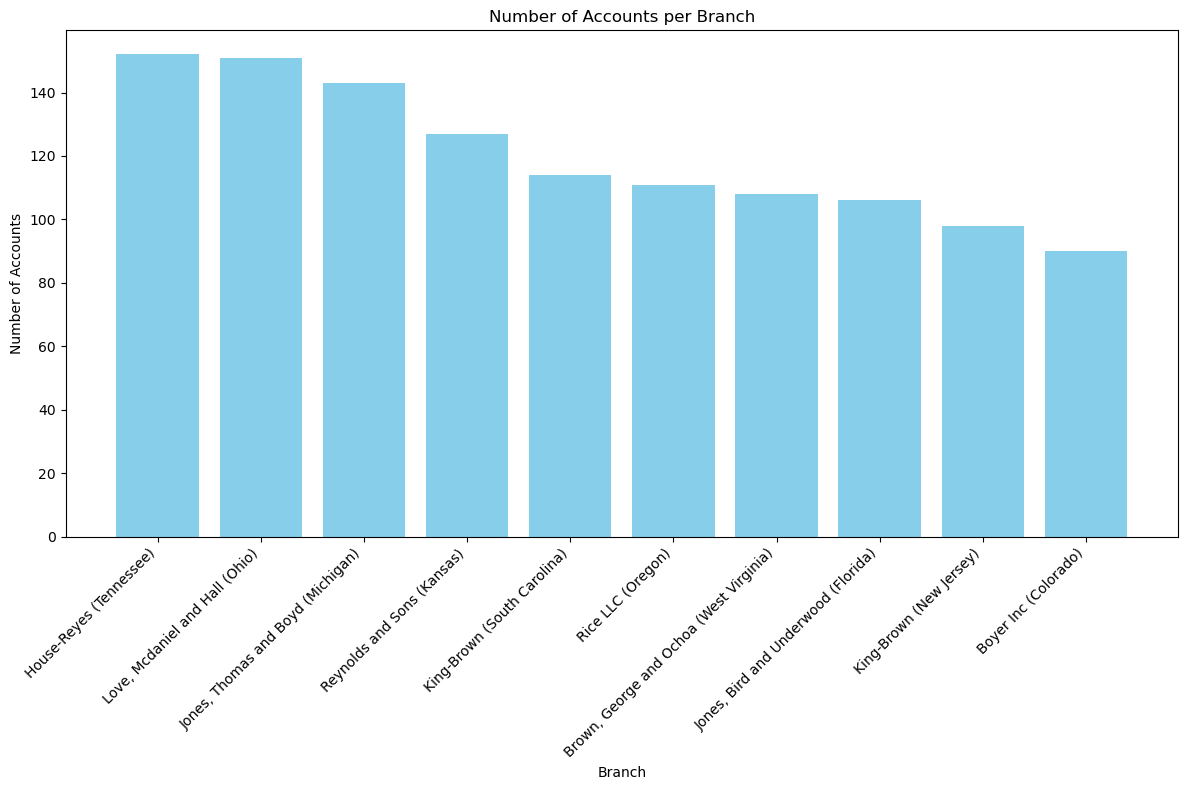

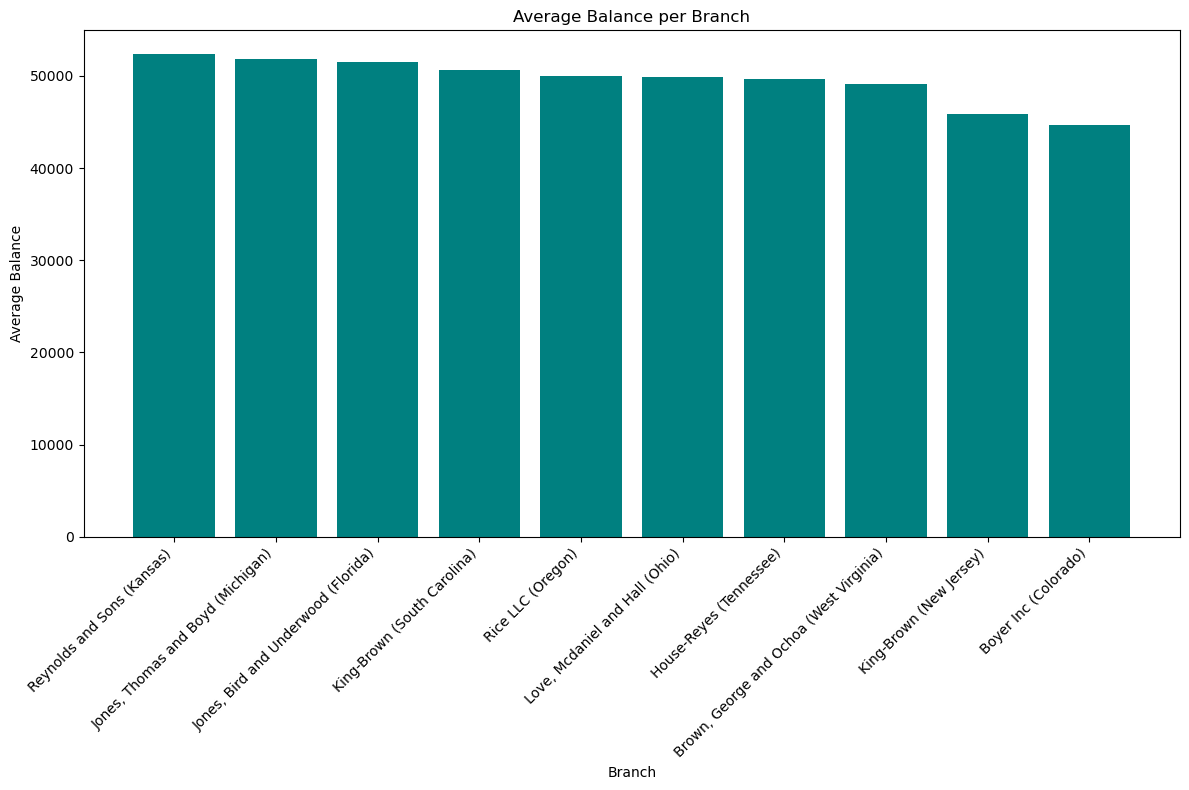

In [25]:
# Create a new column for unique branch label
df_branch_accounts['BranchLabel'] = df_branch_accounts['BranchName'] + ' (' + df_branch_accounts['State'] + ')'

# Bar chart with unique labels
plt.figure(figsize=(12,8))
plt.bar(df_branch_accounts['BranchLabel'], df_branch_accounts['NumAccounts'], color='skyblue')
plt.xlabel('Branch')
plt.ylabel('Number of Accounts')
plt.title('Number of Accounts per Branch')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

df_sorted = df_branch_accounts.sort_values(by='AvgBalance', ascending=False)
plt.figure(figsize=(12,8))
plt.bar(df_sorted['BranchLabel'], df_sorted['AvgBalance'], color='teal')
plt.xlabel('Branch')
plt.ylabel('Average Balance')
plt.title('Average Balance per Branch')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insights:**
This shows that branches with high number of accounts doesnt exactly hold high average balance per month.

# Analysis 2: Customer Activity Overview

**Question:**
Which customers are the most active in terms of number of transactions and total transaction amounts?

In [26]:
query = """
SELECT 
    c.CustomerID,
    c.FirstName,
    c.LastName,
    COUNT(t.TransactionID) AS NumTransactions,
    SUM(t.Amount) AS TotalTransactionAmount
FROM Transactions t
JOIN Accounts a
    ON t.AccountID = a.AccountID
JOIN Customers c
    ON a.CustomerID = c.CustomerID
GROUP BY c.CustomerID, c.FirstName, c.LastName
ORDER BY TotalTransactionAmount DESC
LIMIT 10;
"""

# Execute query and load into a dataframe
df_customer_activity = pd.read_sql_query(query, conn)


print(df_customer_activity)

   CustomerID  FirstName   LastName  NumTransactions  TotalTransactionAmount
0         262      Susan      Estes               54               283211.17
1         725  Francisco      Blake               50               261052.88
2         678       Jose     Vargas               43               243272.89
3         805    Valerie       Park               44               240014.04
4         312   Kathleen  Rodriguez               41               239019.34
5         185       Anna    Simmons               46               228687.71
6         652     Hannah       Cruz               48               223311.51
7         606    Brandon      Roach               47               214555.94
8         562      Jacob      Brown               41               213739.73
9         948     Nicole     Kelley               38               208877.26


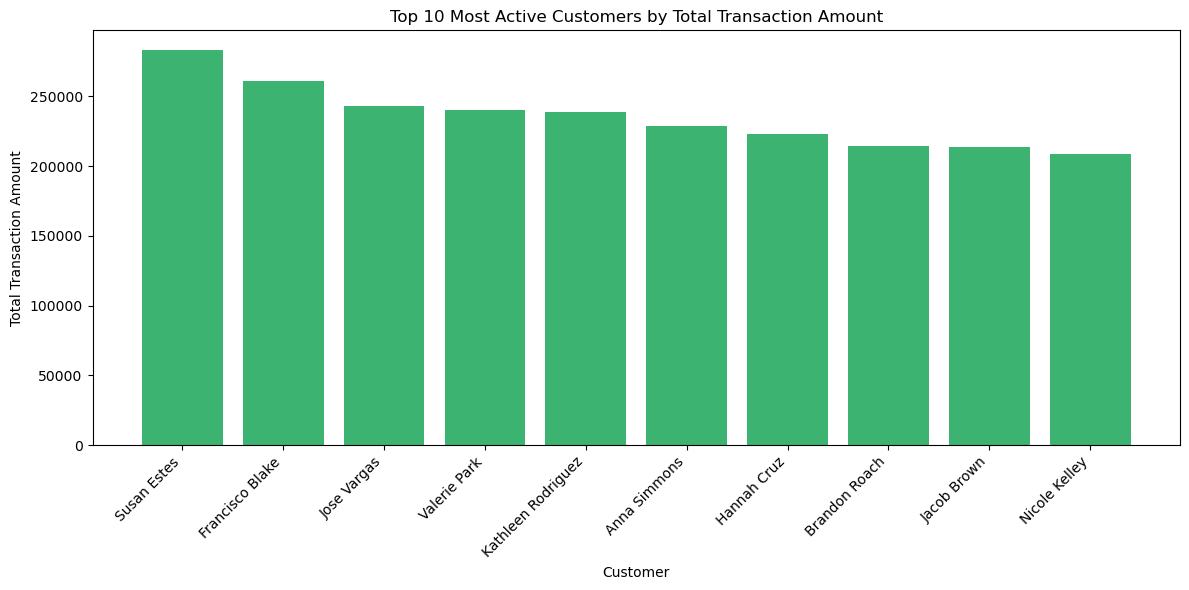

In [27]:
top10 = df_customer_activity
plt.figure(figsize=(12,6))
plt.bar(top10['FirstName'] + ' ' + top10['LastName'], top10['TotalTransactionAmount'], color='mediumseagreen')
plt.xlabel('Customer')
plt.ylabel('Total Transaction Amount')
plt.title('Top 10 Most Active Customers by Total Transaction Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insights:**
The customer activity analysis reveals that Susan Estes is the highest-value customer by total transaction amount and highest number of transactions. Some customers make fewer, larger transactions while others transact more frequently with smaller amounts.

# Analysis 3: Top Customer Transaction Breakdown

**Question:**  
For the top customers by total transaction amount, how are their transactions distributed across Deposit, Withdrawal, and Transfer types?

   CustomerID  FirstName   LastName  TotalDeposit  TotalWithdrawal  \
0         262      Susan      Estes      83681.75         79946.60   
1         725  Francisco      Blake      55170.96         80181.16   
2         678       Jose     Vargas      86046.10        112875.87   
3         805    Valerie       Park      51656.32         93356.30   
4         312   Kathleen  Rodriguez      92975.26         66277.49   
5         185       Anna    Simmons      83676.24         49220.03   
6         652     Hannah       Cruz      73237.61         81307.60   
7         606    Brandon      Roach      67870.76         84111.87   
8         562      Jacob      Brown      80164.52         69069.41   
9         948     Nicole     Kelley      53306.04         86384.45   

   TotalTransfer  
0      119582.82  
1      125700.76  
2       44350.92  
3       95001.42  
4       79766.59  
5       95791.44  
6       68766.30  
7       62573.31  
8       64505.80  
9       69186.77  


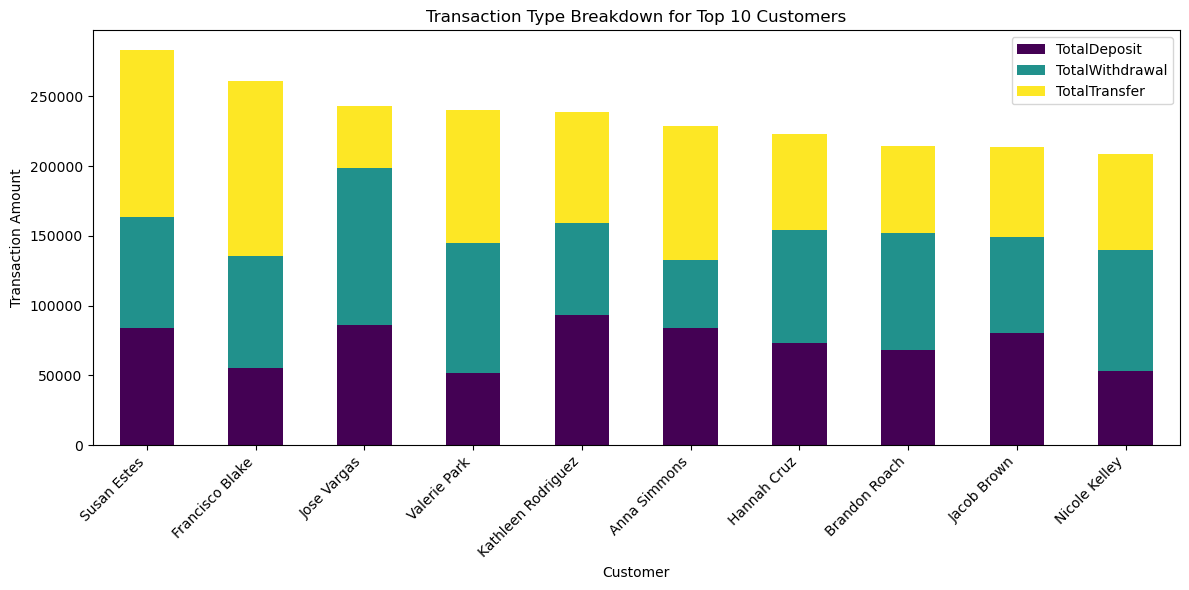

In [28]:

customer_ids = tuple(df_customer_activity['CustomerID'].tolist())

transaction_breakdown_query = f"""
SELECT 
    c.CustomerID,
    c.FirstName,
    c.LastName,
    SUM(CASE WHEN t.TransactionType = 'Deposit' THEN t.Amount ELSE 0 END) AS TotalDeposit,
    SUM(CASE WHEN t.TransactionType = 'Withdrawal' THEN t.Amount ELSE 0 END) AS TotalWithdrawal,
    SUM(CASE WHEN t.TransactionType = 'Transfer' THEN t.Amount ELSE 0 END) AS TotalTransfer
FROM Transactions t
JOIN Accounts a ON t.AccountID = a.AccountID
JOIN Customers c ON a.CustomerID = c.CustomerID
WHERE c.CustomerID IN {customer_ids}
GROUP BY c.CustomerID, c.FirstName, c.LastName
ORDER BY (TotalDeposit + TotalWithdrawal + TotalTransfer) DESC;
"""

df_transaction_breakdown = pd.read_sql_query(transaction_breakdown_query, conn)

# Preview the result
print(df_transaction_breakdown)

# Optional visualization: stacked bar chart
df_transaction_breakdown.set_index(df_transaction_breakdown['FirstName'] + ' ' + df_transaction_breakdown['LastName'], inplace=True)
df_transaction_breakdown[['TotalDeposit','TotalWithdrawal','TotalTransfer']].plot(
    kind='bar', stacked=True, figsize=(12,6), colormap='viridis'
)
plt.xlabel('Customer')
plt.ylabel('Transaction Amount')
plt.title('Transaction Type Breakdown for Top 10 Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insight:**  
The analysis shows that **Transfers contribute the most** to transaction totals among the top 10 customers, while **Deposits contribute the least**. This indicates that high-value customers tend to move money more than they deposit it.  

Some customers, like **Hannah Cruz and Brandon Roach**, show a relatively balanced mix of transaction types, but overall there is **no consistent pattern** across all top customers. Each high-value customer appears to have a unique behavior profile, suggesting that **personalized strategies** may be necessary to engage them effectively.  

# Analysis 4: Branch Transaction Performance

**Question:**  
Which bank branches handle the highest total transaction amounts?

In [29]:
# Analysis 4: Branch Transaction Performance

query = """
SELECT 
    b.BranchID,
    b.BranchName,
    b.City,
    b.State,
    SUM(t.Amount) AS TotalTransactionAmount,
    COUNT(t.TransactionID) AS NumTransactions
FROM Transactions t
JOIN Accounts a ON t.AccountID = a.AccountID
JOIN Customers c ON a.CustomerID = c.CustomerID
JOIN Branches b ON c.BranchID = b.BranchID
GROUP BY b.BranchID, b.BranchName, b.City, b.State
ORDER BY TotalTransactionAmount DESC
"""

df_branch_transactions = pd.read_sql_query(query, conn)

df_branch_transactions.head()

,BranchID,BranchName,City,State,TotalTransactionAmount,NumTransactions
0,10,House-Reyes,Lake Alyssaton,Tennessee,6441115.86,1280
1,1,"Love, Mcdaniel and Hall",Lake Kevinport,Ohio,6239369.16,1284
2,4,"Jones, Thomas and Boyd",West Brooke,Michigan,5991628.73,1193
3,6,Reynolds and Sons,Brianshire,Kansas,5456980.94,1077
4,8,King-Brown,Lake Edward,South Carolina,4707719.65,950


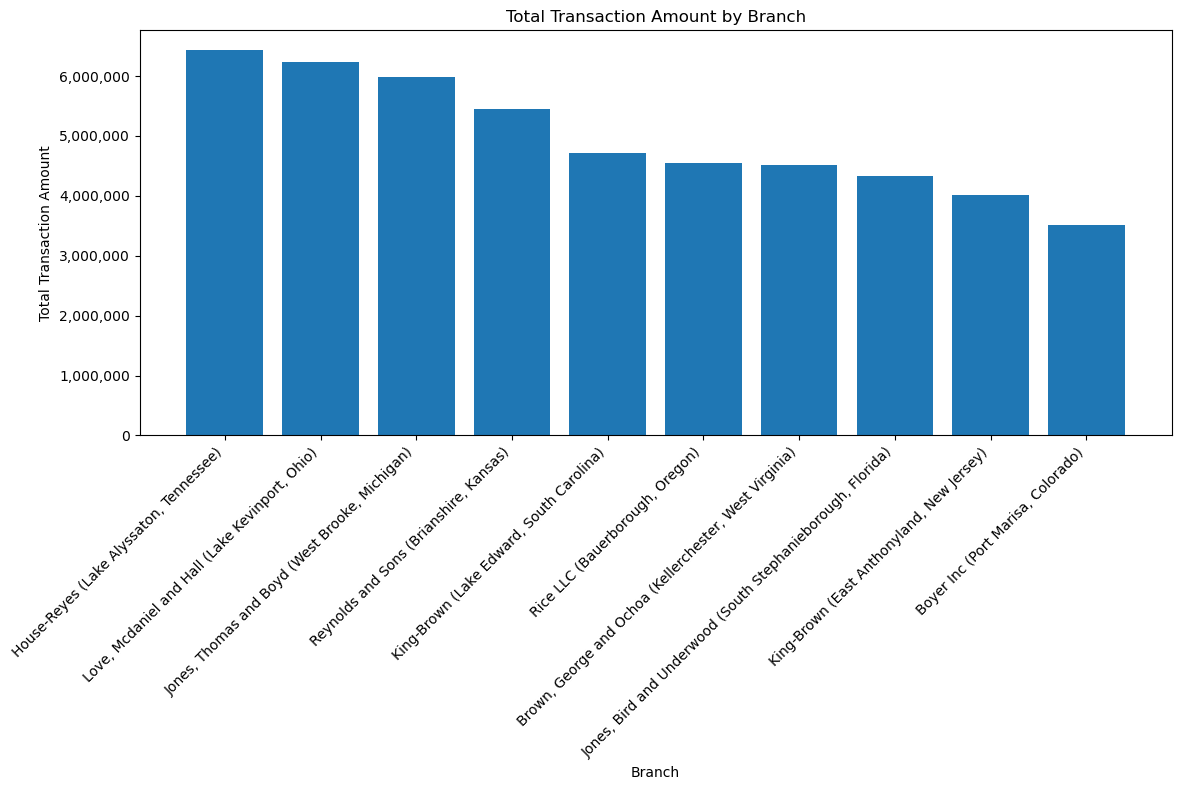

In [33]:
df_sorted = df_branch_transactions.sort_values(by="TotalTransactionAmount", ascending=False)

df_sorted["BranchLabel"] = (
    df_sorted["BranchName"] + " (" + df_sorted["City"] + ", " + df_sorted["State"] + ")"
)

plt.figure(figsize=(12,8))
plt.bar(df_sorted["BranchLabel"], df_sorted["TotalTransactionAmount"])

plt.xlabel("Branch")
plt.ylabel("Total Transaction Amount")
plt.title("Total Transaction Amount by Branch")

plt.xticks(rotation=45, ha="right")

# Format y-axis with commas instead of scientific notation
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()

**Insight:**  
The branch **Love, McDaniel and Hall** records the highest total transaction value, indicating it handles the largest volume of money movement. However, the branch with the **highest number of transactions is House-Reyes**, suggesting that transaction frequency does not necessarily correspond to the highest monetary value.

Overall, transaction totals across branches are **relatively close**, indicating that customer activity is fairly evenly distributed among branches rather than being concentrated in a single location. This suggests a balanced operational workload across the bank’s branch network.

# Analysis 5: Transaction Trends Over Time

**Question:**  
How does transaction activity change over time? Are there noticeable monthly trends in total transaction amounts?

In [40]:
query = """
SELECT 
    strftime('%m', TransactionDate) AS MonthNumber,
    strftime('%m', TransactionDate) AS Month,
    COUNT(TransactionID) AS NumTransactions,
    SUM(Amount) AS TotalTransactionAmount
FROM Transactions
GROUP BY Month
ORDER BY MonthNumber
"""

df_transaction_trends = pd.read_sql_query(query, conn)
import calendar

df_transaction_trends["Month"] = df_transaction_trends["MonthNumber"].astype(int)
df_transaction_trends["Month"] = df_transaction_trends["Month"].apply(lambda x: calendar.month_abbr[x])
print(df_transaction_trends)

   MonthNumber Month  NumTransactions  TotalTransactionAmount
0           01   Jan              819              4020603.65
1           02   Feb              788              3884771.73
2           03   Mar              862              4243969.23
3           04   Apr              809              4004312.44
4           05   May              896              4545390.34
5           06   Jun              748              3786092.49
6           07   Jul              861              4226226.75
7           08   Aug              852              4096636.56
8           09   Sep              859              4439516.91
9           10   Oct              801              3883218.24
10          11   Nov              819              4155355.55
11          12   Dec              886              4484355.16


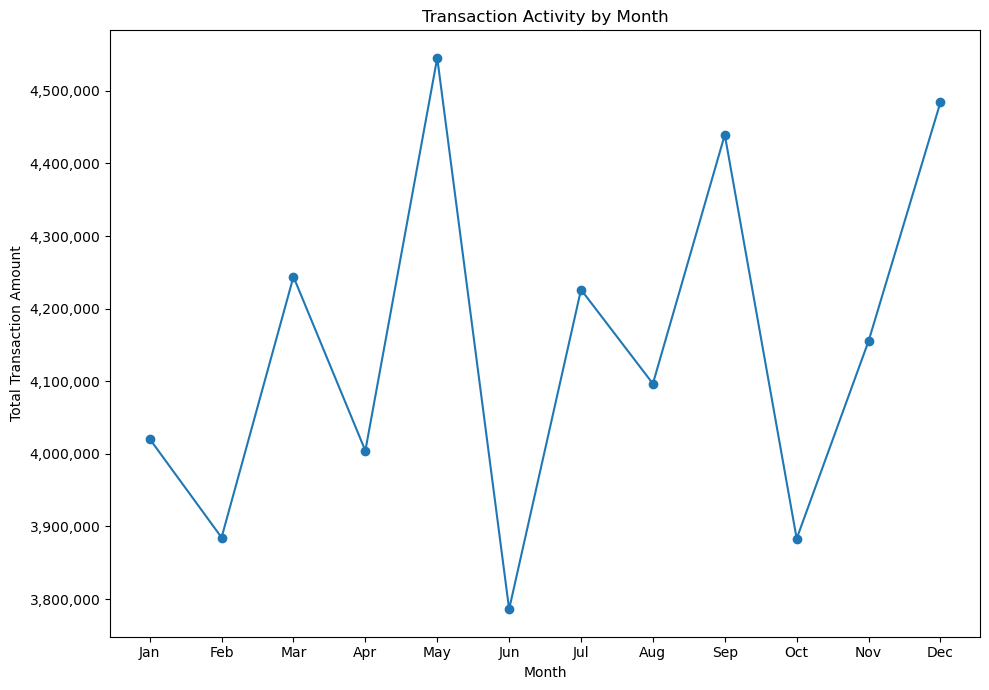

In [43]:
plt.figure(figsize=(10,7))

plt.plot(
    df_transaction_trends["Month"],
    df_transaction_trends["TotalTransactionAmount"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Total Transaction Amount")
plt.title("Transaction Activity by Month")

# Format y-axis with commas
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

**Insight:**  
Transaction activity varies across months rather than remaining uniform throughout the year. **May records the highest total transaction value**, while **June shows the lowest level of activity**.

The chart also reveals **clear spikes in certain months**, indicating that transaction behavior is not evenly distributed over time. These fluctuations may reflect seasonal financial behavior such as increased consumer spending, salary cycles, or periodic financial obligations. Overall, the presence of peaks and troughs suggests that transaction volume may be influenced by temporal factors rather than purely random activity.

# Analysis 6: Loan Portfolio Overview

**Question:**  
What types of loans does the bank issue most frequently, and which loan types represent the largest total loan value?


In [44]:
# Analysis 6: Loan Portfolio Overview

query = """
SELECT 
    LoanType,
    COUNT(LoanID) AS NumberOfLoans,
    SUM(Amount) AS TotalLoanAmount,
    AVG(Amount) AS AvgLoanAmount
FROM Loans
GROUP BY LoanType
ORDER BY TotalLoanAmount DESC
"""

df_loan_portfolio = pd.read_sql_query(query, conn)

df_loan_portfolio

,LoanType,NumberOfLoans,TotalLoanAmount,AvgLoanAmount
0,Car,137,35669541.37,260361.615839
1,Home,121,32132514.98,265557.975041
2,Personal,129,31853277.20,246924.629457
3,Education,113,27273621.56,241359.482832


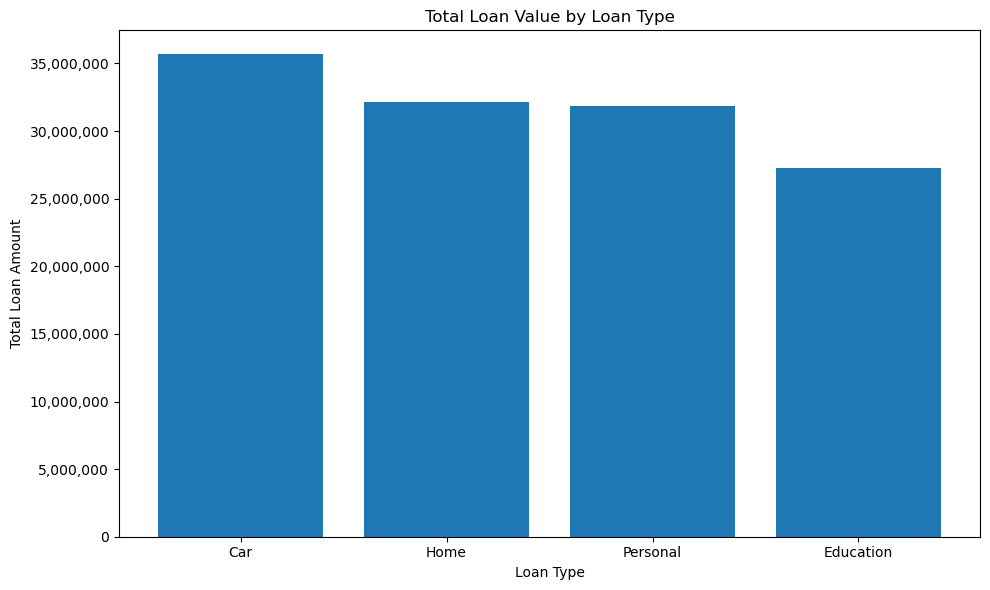

In [45]:
df_sorted = df_loan_portfolio.sort_values(by="TotalLoanAmount", ascending=False)

plt.figure(figsize=(10,6))

plt.bar(df_sorted["LoanType"], df_sorted["TotalLoanAmount"])

plt.xlabel("Loan Type")
plt.ylabel("Total Loan Amount")
plt.title("Total Loan Value by Loan Type")

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

**Insight:**  
The analysis shows that **car loans dominate the bank’s loan portfolio**, having both the **highest number of issued loans and the largest total loan value**. This indicates that vehicle financing represents a major lending activity for the bank and likely reflects strong customer demand for auto loans.

While car loans make up the bulk of issued loans, **home loans have the highest average loan amount**, which is expected given the larger financial scale typically associated with property purchases.

# Analysis 7: Customers with the Largest Loan Amounts

**Question:**  
Which customers hold the largest total loan amounts issued by the bank?

In [46]:
# Analysis 7: Customers with the Largest Loan Amounts

query = """
SELECT 
    c.CustomerID,
    c.FirstName,
    c.LastName,
    COUNT(l.LoanID) AS NumberOfLoans,
    SUM(l.Amount) AS TotalLoanAmount
FROM Loans l
JOIN Customers c
ON l.CustomerID = c.CustomerID
GROUP BY c.CustomerID, c.FirstName, c.LastName
ORDER BY TotalLoanAmount DESC
LIMIT 10
"""

df_top_loan_customers = pd.read_sql_query(query, conn)

df_top_loan_customers

,CustomerID,FirstName,LastName,NumberOfLoans,TotalLoanAmount
0,893,Steven,Lane,3,1210884.46
1,252,Tiffany,Dennis,3,1122946.20
2,475,Linda,Perry,3,1086734.70
3,433,John,Lopez,2,964450.63
4,671,Robert,Norris,2,954378.44
5,294,Ryan,Trujillo,4,914316.87
6,498,Samantha,Rivera,2,906017.79
7,585,Daniel,Hayes,2,885458.75
8,170,David,Mckenzie,3,884907.93
9,747,Heather,Shaffer,4,866516.89


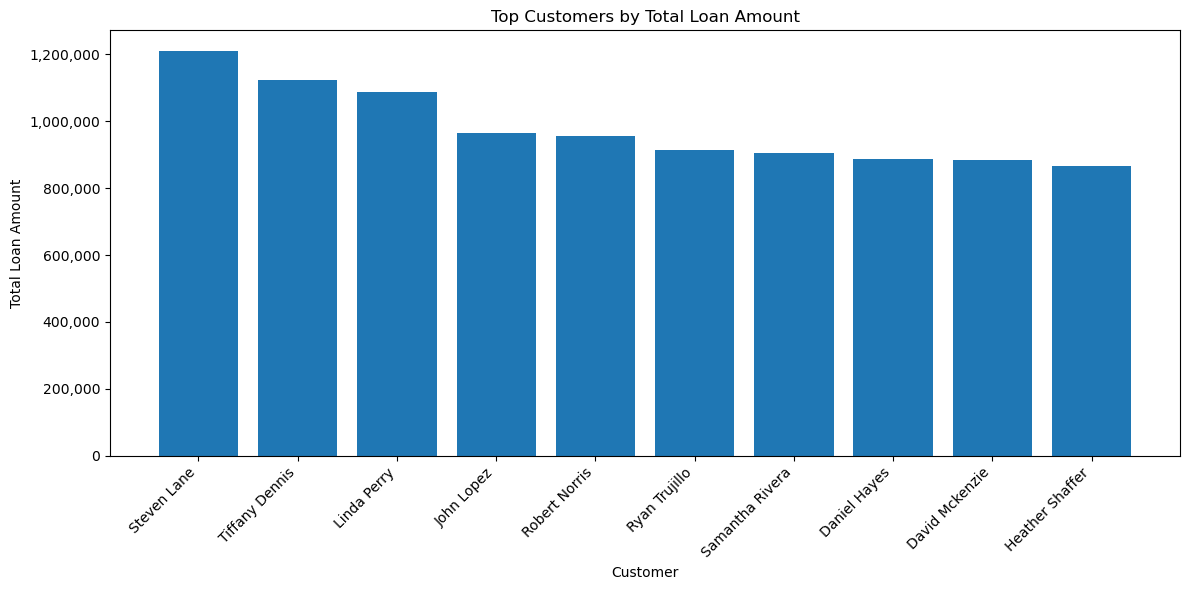

In [47]:
df_top_loan_customers["CustomerName"] = (
    df_top_loan_customers["FirstName"] + " " + df_top_loan_customers["LastName"]
)

plt.figure(figsize=(12,6))

plt.bar(
    df_top_loan_customers["CustomerName"],
    df_top_loan_customers["TotalLoanAmount"]
)

plt.xlabel("Customer")
plt.ylabel("Total Loan Amount")
plt.title("Top Customers by Total Loan Amount")

plt.xticks(rotation=45, ha="right")

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()